In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "output"
CACHE_DIR = os.path.join(BASE_DIR, "cache")
FIG_DIR = os.path.join(BASE_DIR, "figures")
TABLE_DIR = os.path.join(BASE_DIR, "tables")
FINAL_DIR = os.path.join(BASE_DIR, "final")

for d in [BASE_DIR, CACHE_DIR, FIG_DIR, TABLE_DIR, FINAL_DIR]:
    os.makedirs(d, exist_ok=True)

events = pd.read_csv(
    os.path.join(FINAL_DIR, "event_panel_yf.csv"),
    parse_dates=["earnings_datetime", "event_day"]
)

att = pd.read_csv(
    os.path.join(FINAL_DIR, "attention_panel_gtrends.csv"),
    parse_dates=["date"]
)

# Clean column name whitespace just in case
events.columns = [c.strip() for c in events.columns]
att.columns = [c.strip() for c in att.columns]

if att.empty:
    raise ValueError("attention_panel_gtrends.csv is empty. Run Notebook 3 first.")

required_att_cols = {"ticker", "date", "attention_index_z"}
missing = required_att_cols - set(att.columns)
if missing:
    raise ValueError(f"attention_panel_gtrends.csv is missing columns: {missing}")

# Sort for merge_asof
att = att.sort_values(["ticker", "date"]).copy()
events = events.sort_values(["ticker", "event_day"]).copy()

merged_list = []
for tic, g in events.groupby("ticker"):
    a = att[att["ticker"] == tic].sort_values("date").copy()
    if a.empty:
        continue

    e = g.copy()
    e["event_day_dt"] = pd.to_datetime(e["event_day"])
    a["date_dt"] = pd.to_datetime(a["date"])

    m = pd.merge_asof(
        e.sort_values("event_day_dt"),
        a.sort_values("date_dt"),
        left_on="event_day_dt",
        right_on="date_dt",
        direction="backward"
    )

    # Force ticker column to exist and be correct
    m["ticker"] = tic
    merged_list.append(m)

final = pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame()

if final.empty:
    raise ValueError("Merged dataset is empty. Check ticker overlap between event_panel_yf.csv and attention_panel_gtrends.csv.")

# Use attention_index_z as attention
final = final.rename(columns={"attention_index_z": "attention"})

# If present, keep only rows with at least 1 term contributing to attention
if "n_terms_used" in final.columns:
    final = final[final["n_terms_used"] >= 1]

# Drop missing essentials
final = final.dropna(subset=["surprise_car_0_1", "drift_car_2_21", "attention"])

final_path = os.path.join(FINAL_DIR, "final_event_dataset.csv")
final.to_csv(final_path, index=False)

print(f"Saved final dataset to {final_path}")
print("Rows:", len(final), "Tickers:", final["ticker"].nunique() if len(final) else 0)

# Ensure event_day is datetime for time series grouping
final["event_day"] = pd.to_datetime(final["event_day"])

# Create attention regimes for analysis
final["high_attention"] = (final["attention"] > final["attention"].median()).astype(int)

def bucket_by_quantiles(x, q=5):
    return pd.qcut(x, q=q, labels=False, duplicates="drop")

final["surprise_bucket"] = bucket_by_quantiles(final["surprise_car_0_1"], q=5)

summary_cols = ["surprise_car_0_1", "drift_car_2_21", "attention", "earnings_count"]
desc = final[summary_cols].describe().T
desc.to_csv(os.path.join(TABLE_DIR, "final_dataset_summary_stats.csv"))
print("Saved summary stats table to output/tables/final_dataset_summary_stats.csv")

def mean_by_groups(df, group_cols, value_col):
    return df.groupby(group_cols)[value_col].mean().reset_index()

tab1 = mean_by_groups(final, ["high_distraction"], "drift_car_2_21")
tab1.to_csv(os.path.join(TABLE_DIR, "mean_drift_by_distraction.csv"), index=False)

tab2 = mean_by_groups(final, ["high_attention"], "drift_car_2_21")
tab2.to_csv(os.path.join(TABLE_DIR, "mean_drift_by_attention.csv"), index=False)

tab3 = mean_by_groups(final, ["high_distraction", "high_attention"], "drift_car_2_21")
tab3.to_csv(os.path.join(TABLE_DIR, "mean_drift_by_distraction_and_attention.csv"), index=False)

plt.figure()
plt.bar(tab1["high_distraction"].astype(str), tab1["drift_car_2_21"])
plt.title("Average Post-Earnings Drift (CAR 2 to 21) by Distraction Regime")
plt.xlabel("High Distraction Indicator")
plt.ylabel("Average Drift CAR")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mean_drift_by_distraction.png"), dpi=200)
plt.close()

plt.figure()
plt.bar(tab2["high_attention"].astype(str), tab2["drift_car_2_21"])
plt.title("Average Post-Earnings Drift (CAR 2 to 21) by Attention Regime")
plt.xlabel("High Attention Indicator")
plt.ylabel("Average Drift CAR")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mean_drift_by_attention.png"), dpi=200)
plt.close()

top_bucket = final["surprise_bucket"].max()
bottom_bucket = final["surprise_bucket"].min()

trade = final.copy()
trade["signal_long"] = (
    (trade["surprise_bucket"] == top_bucket) &
    (trade["high_distraction"] == 1) &
    (trade["high_attention"] == 0)
).astype(int)

trade["signal_short"] = (
    (trade["surprise_bucket"] == bottom_bucket) &
    (trade["high_distraction"] == 1) &
    (trade["high_attention"] == 0)
).astype(int)

trade["strategy_event_return"] = (
    trade["signal_long"] * trade["drift_car_2_21"] -
    trade["signal_short"] * trade["drift_car_2_21"]
)

daily_strat = trade.groupby("event_day")["strategy_event_return"].mean().sort_index().dropna()
daily_strat.to_csv(os.path.join(TABLE_DIR, "strategy_daily_returns_proxy.csv"))
print("Saved strategy daily return proxy to output/tables/strategy_daily_returns_proxy.csv")

cum = daily_strat.cumsum()
plt.figure()
plt.plot(cum.index, cum.values)
plt.title("Cumulative Strategy Return Proxy Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Proxy")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "strategy_cumulative_return_proxy.png"), dpi=200)
plt.close()

running_max = np.maximum.accumulate(cum.values)
drawdown = cum.values - running_max
plt.figure()
plt.plot(cum.index, drawdown)
plt.title("Strategy Drawdown (Cumulative Return Proxy)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "strategy_drawdown_proxy.png"), dpi=200)
plt.close()

mean_ret = daily_strat.mean()
std_ret = daily_strat.std(ddof=1)
sharpe = float(mean_ret / std_ret) if std_ret > 0 else np.nan

perf = pd.DataFrame({
    "mean_daily_return_proxy": [mean_ret],
    "std_daily_return_proxy": [std_ret],
    "sharpe_proxy": [sharpe],
    "n_days": [len(daily_strat)]
})
perf.to_csv(os.path.join(TABLE_DIR, "strategy_performance_summary.csv"), index=False)
print("Saved performance summary to output/tables/strategy_performance_summary.csv")

preview_cols = [
    "ticker","event_day","surprise_car_0_1","drift_car_2_21","earnings_count",
    "high_distraction","attention","high_attention","signal_long","signal_short"
]
trade[preview_cols].head(200).to_csv(os.path.join(TABLE_DIR, "final_dataset_preview.csv"), index=False)

print("Saved preview table to output/tables/final_dataset_preview.csv")
print("All plots saved to output/figures/")

Saved final dataset to output/final/final_event_dataset.csv
Rows: 238 Tickers: 12
Saved summary stats table to output/tables/final_dataset_summary_stats.csv
Saved strategy daily return proxy to output/tables/strategy_daily_returns_proxy.csv
Saved performance summary to output/tables/strategy_performance_summary.csv
Saved preview table to output/tables/final_dataset_preview.csv
All plots saved to output/figures/


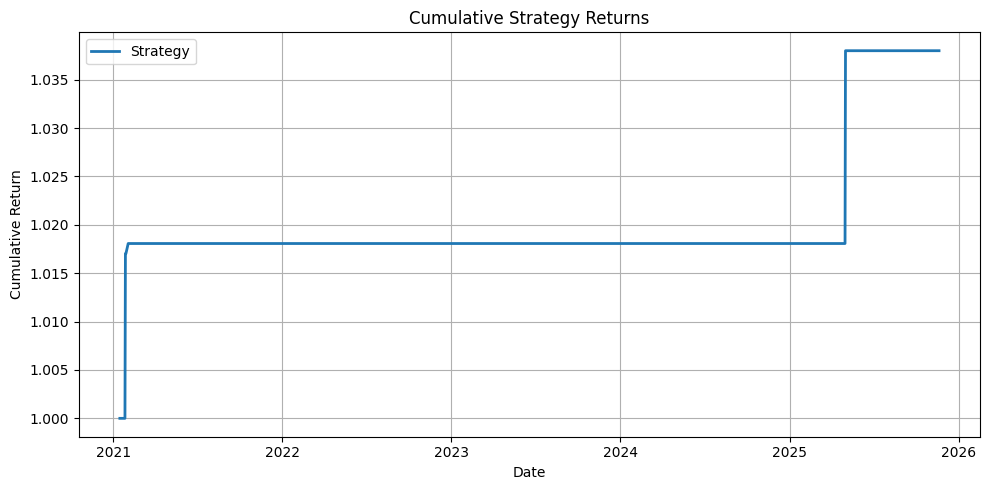

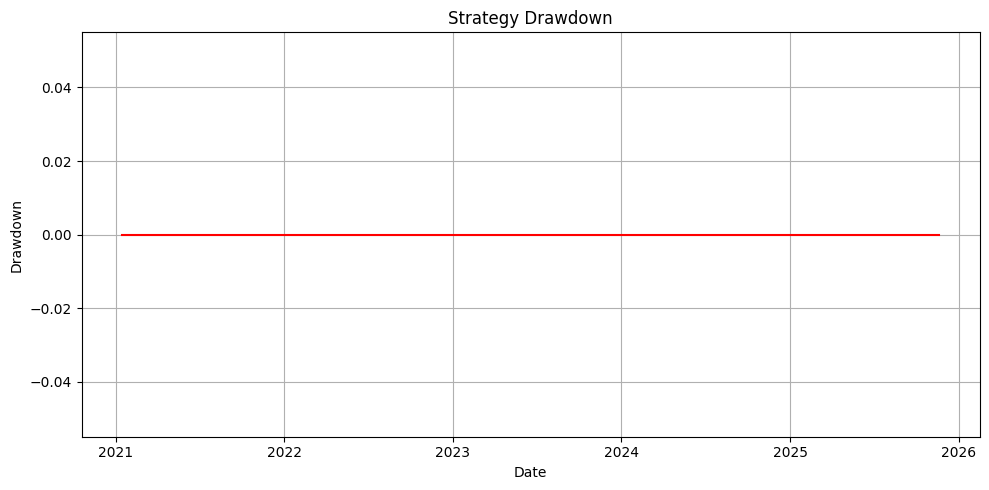

Mean Daily Return: 0.0002
Volatility: 0.0020
Sharpe Ratio: 1.7401
Number of Days: 176.0000


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load strategy returns
returns_df = pd.read_csv("output/tables/strategy_daily_returns_proxy.csv", parse_dates=["event_day"])
returns_df.rename(columns={"strategy_event_return": "strategy_return"}, inplace=True)
returns_df.set_index("event_day", inplace=True)

# Optional: Load SPY returns if available
# spy_df = pd.read_csv("output/final/daily_returns.csv", parse_dates=["date"])
# spy_df.set_index("date", inplace=True)
# returns_df["spy_return"] = spy_df["return"]  # Adjust if needed

# Drop missing
returns_df.dropna(subset=["strategy_return"], inplace=True)

# Compute Sharpe ratio (annualized)
def compute_sharpe(series, risk_free_rate=0.0):
    excess_ret = series - risk_free_rate
    return np.sqrt(252) * excess_ret.mean() / excess_ret.std()

sharpe_strategy = compute_sharpe(returns_df["strategy_return"])

# Cumulative return
cum_returns = (1 + returns_df["strategy_return"]).cumprod()

# Drawdown
running_max = cum_returns.cummax()
drawdown = cum_returns - running_max

# Plot cumulative returns
plt.figure(figsize=(10, 5))
plt.plot(cum_returns, label="Strategy", linewidth=2)
plt.title("Cumulative Strategy Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot drawdown
plt.figure(figsize=(10, 5))
plt.plot(drawdown, label="Drawdown", color='red')
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print summary
summary = {
    "Mean Daily Return": returns_df["strategy_return"].mean(),
    "Volatility": returns_df["strategy_return"].std(),
    "Sharpe Ratio": sharpe_strategy,
    "Number of Days": len(returns_df)
}
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

In [12]:
# --- Save summary stats to CSV ---
summary_df = pd.DataFrame([summary])
summary_df.to_csv("output/tables/strategy_return_summary_metrics.csv", index=False)
print("Saved strategy return summary to output/tables/strategy_return_summary_metrics.csv")

# --- Save cumulative returns to CSV ---
cum_returns_df = cum_returns.rename("cumulative_return").reset_index()
cum_returns_df.to_csv("output/tables/strategy_cumulative_returns.csv", index=False)
print("Saved cumulative returns to output/tables/strategy_cumulative_returns.csv")

# --- Save drawdown to CSV ---
drawdown_df = drawdown.rename("drawdown").reset_index()
drawdown_df.to_csv("output/tables/strategy_drawdown.csv", index=False)
print("Saved drawdown to output/tables/strategy_drawdown.csv")

# --- Save plots ---
plt.figure(figsize=(10, 5))
plt.plot(cum_returns, label="Strategy", linewidth=2)
plt.title("Cumulative Strategy Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("output/figures/cumulative_strategy_returns.png")
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(drawdown, label="Drawdown", color='red')
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.savefig("output/figures/strategy_drawdown.png")
plt.close()

print("Saved final figures to output/figures/")

Saved strategy return summary to output/tables/strategy_return_summary_metrics.csv
Saved cumulative returns to output/tables/strategy_cumulative_returns.csv
Saved drawdown to output/tables/strategy_drawdown.csv
Saved final figures to output/figures/
